# Whole Pipeline


In [5]:
import os
import cv2
from glob import glob

import numpy as np

import matplotlib
import matplotlib.pyplot as plt



In [ ]:
# Data loader
from va_functions.data_loader import load_dataset

# VA functions
from va_functions.new_keypoints import detect_new_candidate_keypoints
from va_functions.triangulation import triangulate_new_landmarks
from va_functions.new_keypoints import add_new_landmarks
from va_functions.estimate_camera_pos import RANSAC_P3P

# Part I
An initialization module that extracts an initial set of 2D ↔ 3D correspondences from the first frames of the sequence and bootstraps the initial camera poses and landmarks.

In [7]:
# Extract initial set of 2D <-> 3D correspondences 



In [8]:
# bootstap the Initial camera poses and landmarks

# Part II
A continuous VO module that processes each frame Ii, estimates the current pose of the camera T i W C using the existing set of landmarks, and regularly triangulates new landmarks.

In [9]:
# Define the mdp

k = 100  # example keypoint count
keypoints_i = np.array((2, k))  # P^(i) = {pik}, k ∈ {1, K}, K = keypoint count
landmarks_i = np.array((2, k))  # X^(i) = {x(p)∀p ∈ P^(i)}, 3D landmarks corresponding to keypoints, x(pik ) is the 3D landmark associated to pik

# For candidate keypoint tracking to determine if new samples are needed
M = 50  # example candidate keypoint count
candidate_keypoints_i = np.array((2, M)) # contain 2 d image coordinates of candidate keypoints in the current frame
candidate_first_observation_i = np.array((2, M)) # contain 2 d image coordinates of candidate keypoints in the first frame they were observed
# TODO: store poses flattened as 12 elements
candidate_camera_poses_i = np.array((4, 4, M)) # contain the camera poses at which the candidate keypoints were first observed

# Load initial S from exercise 07
# TODO: Fix the data loading, for now only hardcoded paths
current_file_location = os.path.dirname(os.path.abspath("__file__"))
relative_path_to_keypoints = "../data/exercise07/keypoints/"
keypoints_path = os.path.join(current_file_location, relative_path_to_keypoints)
# print("Keypoints path: ", keypoints_path)
keypoints_path = '/home/kjanssen/eth/aut25/vision_alg/va_final_prj/src/data/exercise_07/keypoints.txt'
keypoints_i = np.loadtxt(keypoints_path) # dim: num_keypoints x 2

relative_path_to_landmarks = "../data/exercise07/landmarks/"
landmarks_path = os.path.join(current_file_location, relative_path_to_landmarks)
# print("Landmarks path: ", landmarks_path)
landmarks_path = '/home/kjanssen/eth/aut25/vision_alg/va_final_prj/src/data/exercise_07/p_W_landmarks.txt'
landmarks_i = np.loadtxt(landmarks_path)

# Sample 5 % of keypoints as candidate keypoints
num_candidate_keypoints = max(1, int(0.05 * keypoints_i.shape[0]))
candidate_indices = np.random.choice(keypoints_i.shape[0], num_candidate_keypoints, replace=False)
candidate_keypoints_i = keypoints_i[candidate_indices] # They are tracked through the frames
candidate_first_observation_i = candidate_keypoints_i.copy() # They stay the same once assigned

# TODO store poses flattened as 12 elements
# store eye(4) x num_candidate_keypoints
candidate_camera_poses_i = np.repeat(np.eye(4)[np.newaxis, :, :], num_candidate_keypoints, axis=0)

# Prune candidates from main keypoints
keypoints_i = np.delete(keypoints_i, candidate_indices, axis=0)
landmarks_i = np.delete(landmarks_i, candidate_indices, axis=0)


# State dict
S = dict()
S = {"P": keypoints_i, 
     "X": landmarks_i,
     "C": candidate_keypoints_i,
     "F": candidate_first_observation_i,
     "T": candidate_camera_poses_i
    }

image_dir = '/home/kjanssen/eth/aut25/vision_alg/va_final_prj/src/data/exercise_07/left/000000.png'
image_idx = 0
image = cv2.imread('/home/kjanssen/eth/aut25/vision_alg/va_final_prj/src/data/exercise_07/left/%06d.png' % image_idx, cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Error loading image at index ", image_idx)

# Initialize global camera pose storage
# TODO flaten all of this to 12 elements
initial_camera_pose = np.eye(4)  # Assuming starting at origin
global_camera_poses = [initial_camera_pose]

# TODO do we want to store all landmarks to create a global map?


# load K
K = np.loadtxt('/home/kjanssen/eth/aut25/vision_alg/va_final_prj/src/data/exercise_07/K.txt')

In [10]:
#Associate keypoints in the current frame to previously triangulated landmarks

# get keypoints of the previous frame

# get next image
image_idx += 1
image_next = cv2.imread('/home/kjanssen/eth/aut25/vision_alg/va_final_prj/src/data/exercise_07/left/%06d.png' % image_idx, cv2.IMREAD_GRAYSCALE)


# use KLT to track keypoints between frames (previous frame -> current frame)
# TODO investigate pyramid construction like in cv2.buildOpticalFlowPyramid
# TODO investigate: cv2.goodFeaturesToTrack, cv.TermCriteria
# use cv2.calcOpticalFlowPyrLK.
# Swap x and y coordinates of keypoints for cv2
S["P"] = S["P"][:, ::-1]  # now shape is (k, 2) with (x, y) coordinates
print("shape of keypoints to track: ", S["P"].shape)
P_next_candidates, status, error = cv2.calcOpticalFlowPyrLK(
                                            prevImg = image, 
                                            nextImg = image_next, 
                                            prevPts = S["P"].astype(np.float32), 
                                            nextPts = None)

print("Tracked keypoints shape: ", P_next_candidates.shape)
print("Status.shape: ", status.shape)
print("Error.shape: ", error.shape)


# # TODO: --- Investigate if filtering like this is better or better filter via RANSAC ---
# # filter only successfully tracked keypoints
# P_next = P_next_candidates[status.flatten() == 1]
# print("Filtered tracked keypoints shape: ", P_next.shape)

# # filter corresponding landmarks for next step
# X_next = S["X"][status.flatten() == 1]
# print("Corresponding landmarks shape: ", X_next.shape)



shape of keypoints to track:  (491, 2)
Tracked keypoints shape:  (491, 2)
Status.shape:  (491, 1)
Error.shape:  (491, 1)


In [ ]:
#Based on this, estimate the current camera pose

# use RANSAC P3P to robustly estimate the current camera pose and outlier filtering
# use cv2.findFundamentalMat (look at cv2.solvePnPRansac for reference)
    
R_C_W, t_C_W, inlier_mask = RANSAC_P3P(S["P"], P_next_candidates,  K)
print("Estimated Rotation:\n", R_C_W)
print("Estimated Translation:\n", t_C_W)


    

P shape:  (491, 2)
P_next shape:  (491, 2)
Estimated Rotation:
 [[ 0.9307738   0.14766808 -0.33444621]
 [ 0.15908698  0.6600557   0.73417832]
 [ 0.32916783 -0.73655998  0.59087049]]
Estimated Translation:
 [[0.90957095]
 [0.41554293]
 [0.00218099]]


In [12]:
# Bookkeeping of camera poses and landmarks

# Compare inlier_mask of RANSAC and KLT
print("Inlier count from KLT: ", np.count_nonzero(status))
print("Inlier count from RANSAC: ", np.count_nonzero(inlier_mask))

# choose the one from RANSAC for now
# prune lost landmarks
# update keypoints_i and landmarks_i accordingly
keypoints_next = P_next_candidates[inlier_mask]
landmarks_next = S["X"][inlier_mask]

# Store the current camera pose globally
old_pos_T = global_camera_poses[-1]
new_rel_T = np.vstack((np.hstack((R_C_W, t_C_W)), [0, 0, 0, 1]))
current_camera_pose = old_pos_T @ new_rel_T
global_camera_poses.append(current_camera_pose)


Inlier count from KLT:  472
Inlier count from RANSAC:  471


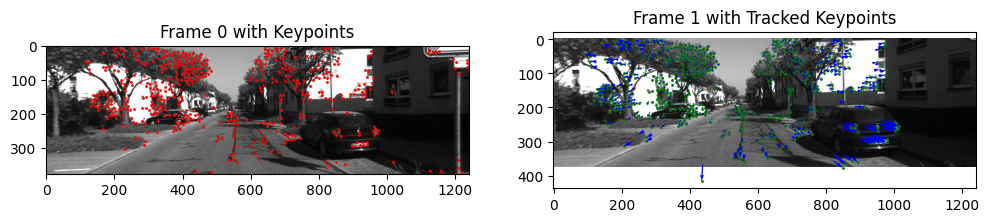

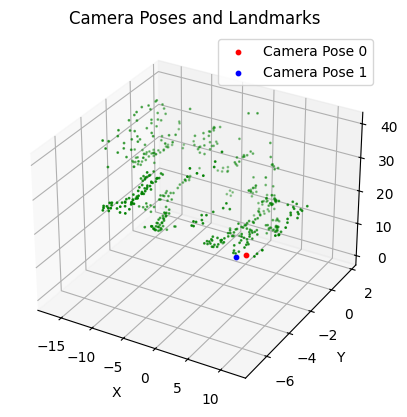

In [13]:
# Visualize 


# print the first image and the keypoints from the first frame and the second image with tracked keypoints next to it
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Frame 0 with Keypoints")
plt.imshow(image, cmap='gray')
plt.scatter(S["P"][ :,0], S["P"][ :,1], c='r', s=1)

plt.subplot(1, 2, 2)
plt.title("Frame 1 with Tracked Keypoints")
plt.imshow(image_next, cmap='gray')
plt.scatter(keypoints_next[ :,0], keypoints_next[ :,1], c='g', s=1)
# add the flow lines
plt.quiver(S["P"][inlier_mask, 0], S["P"][inlier_mask, 1],
           keypoints_next[:, 0] - S["P"][inlier_mask, 0],
           keypoints_next[:, 1] - S["P"][inlier_mask, 1],
           angles='xy', scale_units='xy', scale=1, color='b', width=0.003)
plt.show()


# Creat a 3D view of the camera poses and landmarks
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.set_title("Camera Poses and Landmarks")
# plot landmarks
ax.scatter(landmarks_next[:, 0], landmarks_next[:, 1], landmarks_next[:, 2], c='g', s=1)
# plot camera poses
# plot initial camera pose
ax.scatter(0, 0, 0, c='r', s=10, label='Camera Pose 0')
# plot next camera pose
camera_position_next = -R_C_W.T @ t_C_W
ax.scatter(camera_position_next[0], camera_position_next[1], camera_position_next[2], c='b', s=10, label='Camera Pose 1')
ax.legend()
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()


In [14]:
S = add_new_landmarks(S, image, image_next, K, global_camera_poses)